<a href="https://colab.research.google.com/github/rongxie2023/dlcv/blob/main/01-Understanding_selectivesearch.ipynb" target="_blank"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# %pip install selectivesearch
# %pip install torch_snippets
from torch_snippets import *
import selectivesearch
from skimage.segmentation import felzenszwalb

In [11]:
# !wget -q https://www.dropbox.com/s/lpw10qawsc5ipbn/MyImage.JPG -O MyImage.jpg
# img = read('../data/n04037443_racer.JPEG', 1)
img = read('../data/n02279972_monarch.JPEG', 1)


In [12]:
segments_fz = felzenszwalb(img, scale=200)

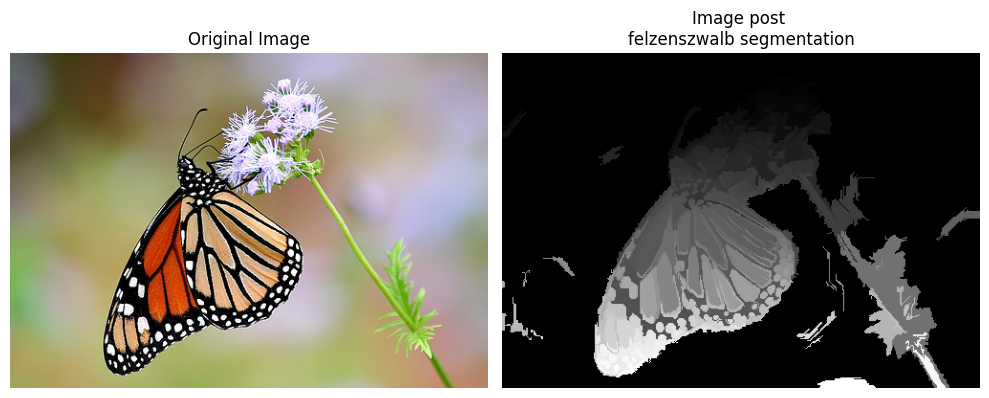

In [13]:
subplots([img, segments_fz], titles=['Original Image','Image post \nfelzenszwalb segmentation'], figsize=(10,10), nc=2)

In [14]:
def extract_candidates(img):
    img_lbl, regions = selectivesearch.selective_search(img, scale=200, min_size=100)
    img_area = np.prod(img.shape[:2])
    candidates = []
    for r in regions:
        if r['rect'] in candidates: continue
        if r['size'] < (0.05*img_area): continue
        if r['size'] > (1*img_area): continue
        x, y, w, h = r['rect']
        candidates.append(list(r['rect']))
    return candidates


In [17]:
# %pip install selectivesearch
# %pip install torch_snippets
from torch_snippets import *
import selectivesearch


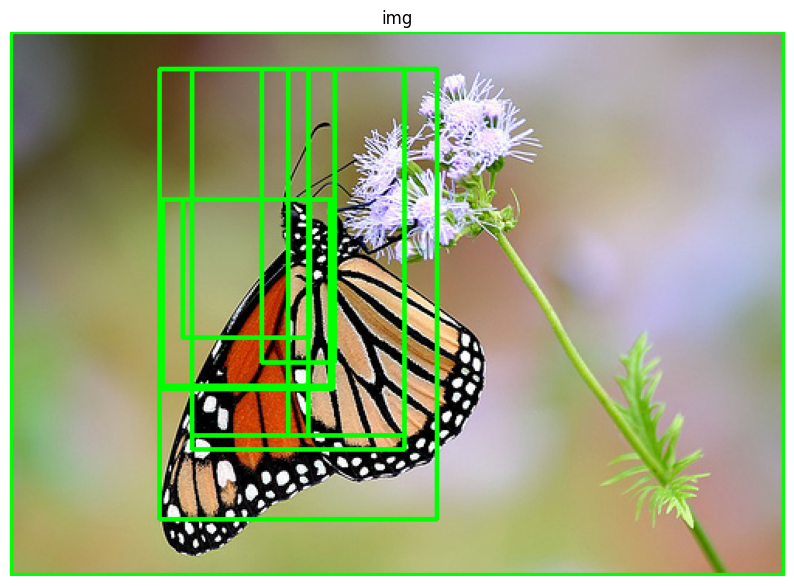

In [18]:
candidates = extract_candidates(img)
show(img, bbs = candidates)